#Assignment 1 - Speech Processing
##PRIYANK ARORA- 2024AA05987
##K.ROMA PAI - 2024aa05965
##SHIVAM DWIVEDI- 2024aa05951

##Part 2: Preprocess the Audio

In [1]:
# Install required libraries
!pip install librosa soundfile -q

import librosa
import soundfile as sf
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

print("PART 2: AUDIO PREPROCESSING ===")
print("Upload your TWO speech samples (.wav or .mp3)")

# FILE UPLOAD
uploaded = files.upload()
audio_files = list(uploaded.keys())[:2]

preprocessed_paths = []

for i, file_name in enumerate(audio_files):
    print(f"\n🔄 Processing {i+1}: {file_name}")

    # Load audio (mono, original sr)
    y, sr = librosa.load(file_name, sr=None, mono=True)
    print(f"  Original: {len(y)/sr:.2f}s @ {sr}Hz")

    # STEP 1: Trim silence
    y_trim, _ = librosa.effects.trim(y, top_db=25)
    print(f"   After trim: {len(y_trim)/sr:.2f}s")

    # STEP 2: Normalize [-1,1]
    y_norm = y_trim / np.max(np.abs(y_trim))

    # STEP 3: Resample 16kHz
    target_sr = 16000
    if sr != target_sr:
        y_resampled = librosa.resample(y_norm, orig_sr=sr, target_sr=target_sr)
        final_sr = target_sr
    else:
        y_resampled = y_norm
        final_sr = sr

    # SAVE PREPROCESSED
    output_file = f"preprocessed_sample_{i+1}.wav"
    sf.write(output_file, y_resampled, final_sr)
    preprocessed_paths.append(output_file)
    print(f"  SAVED: {output_file}")

print(f"\n Part 2 Complete! Files: {preprocessed_paths}")

PART 2: AUDIO PREPROCESSING ===
Upload your TWO speech samples (.wav or .mp3)


Saving Speech 5.wav to Speech 5 (1).wav
Saving Speech 4.wav to Speech 4 (1).wav

🔄 Processing 1: Speech 5 (1).wav
  Original: 11.52s @ 48000Hz
   After trim: 11.09s
  SAVED: preprocessed_sample_1.wav

🔄 Processing 2: Speech 4 (1).wav
  Original: 11.61s @ 48000Hz
   After trim: 10.93s
  SAVED: preprocessed_sample_2.wav

 Part 2 Complete! Files: ['preprocessed_sample_1.wav', 'preprocessed_sample_2.wav']


##PART 3: Mel Spectrogram Extraction

PART 3: MEL SPECTROGRAM EXTRACTION 

🔄 Extracting Mel spectrogram: preprocessed_sample_1.wav


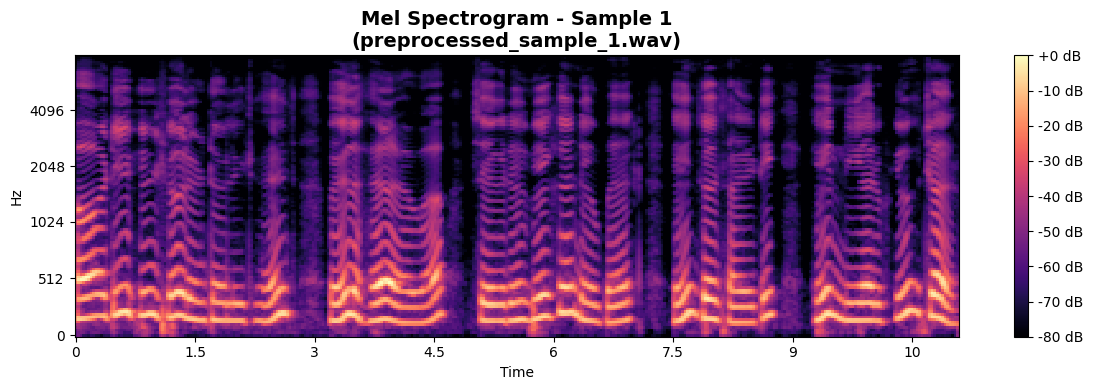

  Shape: (128, 347) (128 mel × 347 frames)

🔄 Extracting Mel spectrogram: preprocessed_sample_2.wav


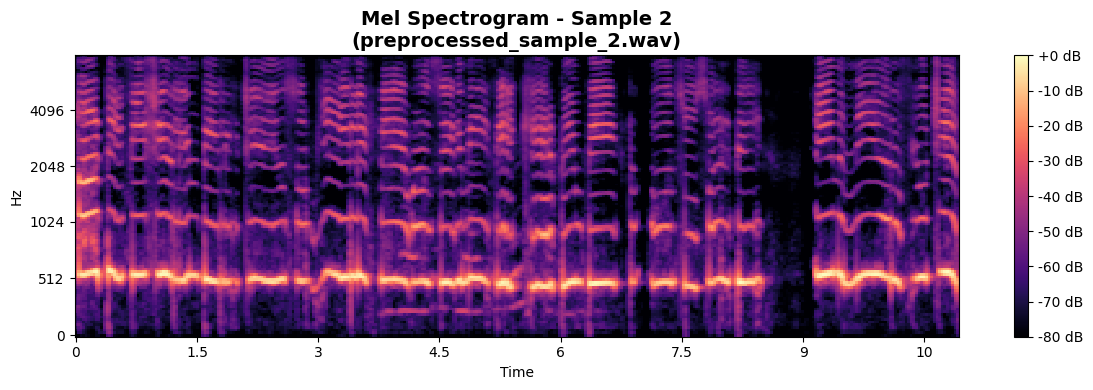

  Shape: (128, 342) (128 mel × 342 frames)


In [2]:
# PART 3: EXTRACT MEL SPECTROGRAM FEATURES

import librosa
import matplotlib.pyplot as plt
import numpy as npk

print("PART 3: MEL SPECTROGRAM EXTRACTION ")

# Load preprocessed files from Part 2
mel_features = []

for i, file_path in enumerate(preprocessed_paths):
    print(f"\n🔄 Extracting Mel spectrogram: {file_path}")

    # Load processed audio
    y, sr = librosa.load(file_path, sr=16000)

    # MEL SPECTROGRAM (128 mel bands, 8kHz max)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)

    mel_features.append(S_dB)

    # PLOT SPECTROGRAM
    plt.figure(figsize=(12, 4))
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', fmax=8000)
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'Mel Spectrogram - Sample {i+1}\n({file_path})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  Shape: {S_dB.shape} (128 mel × {S_dB.shape[1]} frames)")



###Timing differences:
Both samples run for roughly 0–10 s, but the vertical “stripe” patterns (corresponding to syllables and phonemes) are not consistent, in some region stripe 1's samples are more spread out while n sample two same stripes are compressed.
Horizontal spacing between two blocks that the modifies speech gains pace and slows down at differnt points rather than uniform rate.
###Energy Differences:
In both spectrograms, bright orange/yellow bands at lower and mid frequencies mark high‑energy parts of the sentence.
Some segements in Sample 2 show more concentrated, intense bright regions than the matching areas in Sample 1, suggesting that in the modified recording certain syllables are produced with larger force/energy.
###Pitch differences:
The main horizontal bands (harmonics and formants) occur at similar frequency heights, most of the time pitch is unchanged in both samples.
Sample 1 shows slightly more clearly separated horizontal harmonic bands, while in Sample 2 the same bands less distinct, indicating small changes in pitch.

##PART 4: Compare Mel Spectrograms

PART 4: SPECTROGRAM COMPARISON
Methods: Cosine Similarity + Dynamic Time Warping (DTW)

🔸 Cosine Similarity (aligned): 0.9497
🔸 DTW Distance: 68099.39
   (Lower=better alignment despite speed/pitch differences)


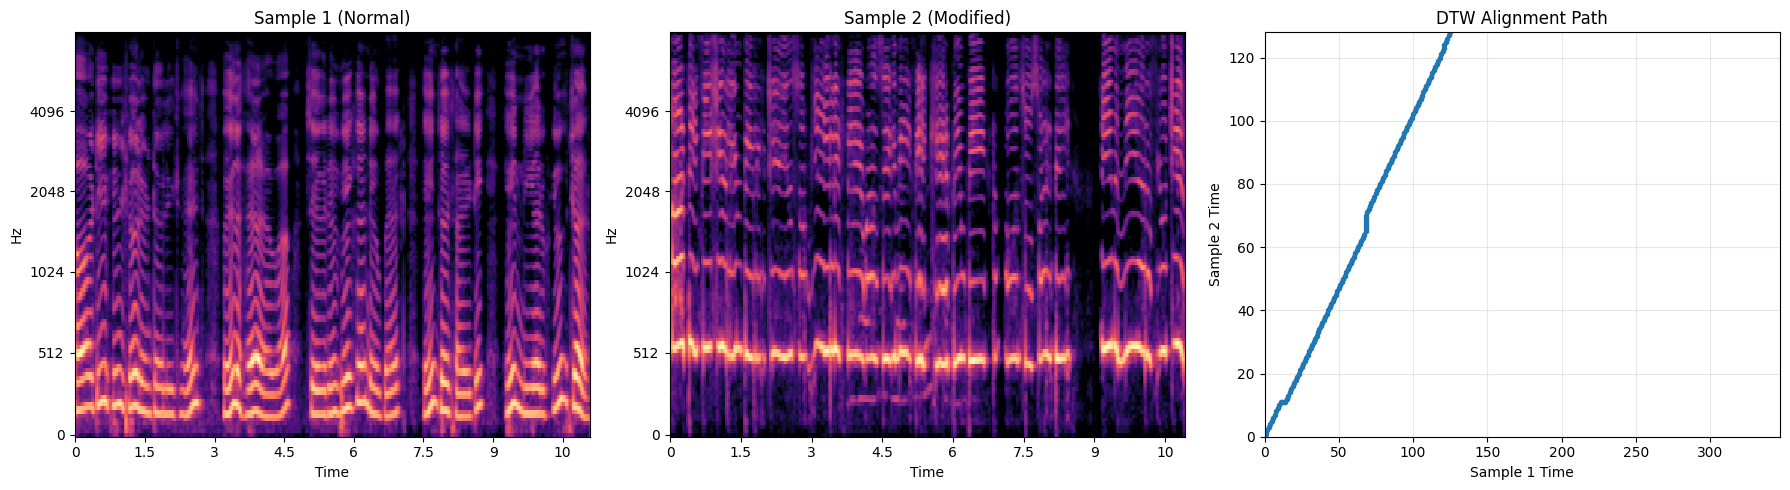

In [5]:
# PART 4: COMPARE MEL SPECTROGRAMS (2 Marks)
# Cosine Similarity + DTW + Visual interpretation

from scipy.spatial.distance import cosine
import librosa
import matplotlib.pyplot as plt
import numpy as np

print("PART 4: SPECTROGRAM COMPARISON")
print("Methods: Cosine Similarity + Dynamic Time Warping (DTW)")

def pad_spectrograms(mel1, mel2):
    """Pad shorter Mel spectrogram with zeros on time axis to match shapes"""
    len1 = mel1.shape[1]
    len2 = mel2.shape[1]
    max_len = max(len1, len2)

    def pad_mel(mel, max_len):
        if mel.shape[1] < max_len:
            pad_width = max_len - mel.shape[1]
            return np.pad(mel, ((0,0), (0, pad_width)), mode='constant', constant_values=(0,))
        else:
            return mel[:, :max_len]

    mel1_padded = pad_mel(mel1, max_len)
    mel2_padded = pad_mel(mel2, max_len)

    return mel1_padded, mel2_padded

# Assign mel spectrograms from the `mel_features` list
mel1 = mel_features[0]
mel2 = mel_features[1]

# COSINE SIMILARITY (Global feature similarity)

mel1_aligned, mel2_aligned = pad_spectrograms(mel1, mel2)

# Then flatten and compute cosine similarity
mel1_flat = mel1_aligned.flatten()
mel2_flat = mel2_aligned.flatten()
cos_sim = 1 - cosine(mel1_flat, mel2_flat)

print(f"\n🔸 Cosine Similarity (aligned): {cos_sim:.4f}")

# DTW (Temporal alignment for speed differences)
D, wp = librosa.sequence.dtw(X=mel1, Y=mel2, metric='euclidean')
dtw_dist = D[-1, -1]
print(f"🔸 DTW Distance: {dtw_dist:.2f}")
print("   (Lower=better alignment despite speed/pitch differences)")

# VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original spectrograms side-by-side
librosa.display.specshow(mel1, sr=16000, x_axis='time', y_axis='mel', ax=axes[0])
axes[0].set(title='Sample 1 (Normal)')
librosa.display.specshow(mel2, sr=16000, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set(title='Sample 2 (Modified)')

# DTW path
axes[2].plot(wp[:, 0], wp[:, 1], marker='o', markersize=3, linewidth=2)
axes[2].set_xlim([0, mel1.shape[1]])
axes[2].set_ylim([0, mel2.shape[0]])
axes[2].set_xlabel('Sample 1 Time')
axes[2].set_ylabel('Sample 2 Time')
axes[2].set_title('DTW Alignment Path')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Reflection on spectrogram changes

1. Both the samples are almost same can be seen by high cosine similarity.

2. Between Sample 1 and Sample 2 the overall pattern of formant bands and harmonics remains similar, but in Sample 2 these vertical stripe structures are more compressed along the time axis, showing that the same phonetic content is spoken faster.​

3. The two Spectrograms show very similar vertical stripe patterns and formant structures, meaning the phonetic content and overall spectral shape are almost the same.

4. Pitch stays broadly in the same range because the main horizontal bands appear at similar frequency heights, however few chnages can be seen in two Spectograms.

5. In Sample 1, the energy at lower frequency is more (can be seen by bright areas in low energy bands).  However in there is clear distinction between high and low at particular frequency bands and seeing the bright regions at higher frequency bands, pitch is a bit higher in Sample 2.

6. The main visual change is that some syllable blocks in Sample 2 are slightly compressed or shifted compared to Sample 1.

7. The **DTW path** is not diagonal, indicating small local timing differences even though the overall duration is mostly same.


